<a href="https://colab.research.google.com/github/mukeshdhadhariya/college_mini_project/blob/main/college_project_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# If needed:
# pip install gymnasium torch matplotlib pandas

import gymnasium as gym
import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Categorical
import numpy as np
import matplotlib.pyplot as plt
import csv
import os

In [3]:
# -----------------------------
# 1. Create environment
# -----------------------------
env = gym.make("CartPole-v1")
state_dim = env.observation_space.shape[0]   # 4 features
action_dim = env.action_space.n              # 2 actions: left, right

In [4]:
# -----------------------------
# 2. Perceptron policy network
#    Single linear layer = perceptron style
# -----------------------------
class PerceptronPolicy(nn.Module):
    def __init__(self, input_dim, output_dim):
        super().__init__()
        self.fc = nn.Linear(input_dim, output_dim)

    def forward(self, x):
        return self.fc(x)

policy = PerceptronPolicy(state_dim, action_dim)
optimizer = optim.Adam(policy.parameters(), lr=0.01)

gamma = 0.99
num_episodes = 600
reward_history = []


In [5]:
# -----------------------------
# 3. Helper: choose action
# -----------------------------
def choose_action(state):
    state = torch.tensor(state, dtype=torch.float32)
    logits = policy(state)
    probs = torch.softmax(logits, dim=0)
    dist = Categorical(probs)
    action = dist.sample()
    return action.item(), dist.log_prob(action)

In [6]:
# -----------------------------
# 4. Helper: compute discounted returns
# -----------------------------
def compute_returns(rewards, gamma):
    returns = []
    R = 0
    for r in reversed(rewards):
        R = r + gamma * R
        returns.append(R)
    returns.reverse()

    returns = torch.tensor(returns, dtype=torch.float32)
    if len(returns) > 1:
        returns = (returns - returns.mean()) / (returns.std() + 1e-8)
    return returns

In [7]:
# -----------------------------
# 5. Optional: save transitions as CSV
#    This becomes your "dataset"
# -----------------------------
csv_file = "cartpole_transitions.csv"
write_header = not os.path.exists(csv_file)

with open(csv_file, "a", newline="") as f:
    writer = csv.writer(f)
    if write_header:
        writer.writerow([
            "episode", "step",
            "s1", "s2", "s3", "s4",
            "action", "reward",
            "ns1", "ns2", "ns3", "ns4",
            "done"
        ])

    # -----------------------------
    # 6. Training loop
    # -----------------------------
    for episode in range(num_episodes):
        state, info = env.reset(seed=episode)
        log_probs = []
        rewards = []
        total_reward = 0
        step_count = 0
        done = False

        while not done:
            action, log_prob = choose_action(state)
            next_state, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated

            # Save one transition
            writer.writerow([
                episode, step_count,
                state[0], state[1], state[2], state[3],
                action, reward,
                next_state[0], next_state[1], next_state[2], next_state[3],
                int(done)
            ])

            log_probs.append(log_prob)
            rewards.append(reward)
            total_reward += reward
            state = next_state
            step_count += 1

        # -----------------------------
        # 7. Policy gradient update
        # -----------------------------
        returns = compute_returns(rewards, gamma)

        loss = 0
        for log_prob, R in zip(log_probs, returns):
            loss += -log_prob * R

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        reward_history.append(total_reward)

        if (episode + 1) % 20 == 0:
            avg_reward = np.mean(reward_history[-20:])
            print(f"Episode {episode+1:4d} | Avg Reward (last 20): {avg_reward:.2f}")


Episode   20 | Avg Reward (last 20): 19.40
Episode   40 | Avg Reward (last 20): 23.45
Episode   60 | Avg Reward (last 20): 27.90
Episode   80 | Avg Reward (last 20): 27.30
Episode  100 | Avg Reward (last 20): 30.35
Episode  120 | Avg Reward (last 20): 34.00
Episode  140 | Avg Reward (last 20): 32.95
Episode  160 | Avg Reward (last 20): 42.15
Episode  180 | Avg Reward (last 20): 37.65
Episode  200 | Avg Reward (last 20): 58.35
Episode  220 | Avg Reward (last 20): 64.80
Episode  240 | Avg Reward (last 20): 62.00
Episode  260 | Avg Reward (last 20): 56.40
Episode  280 | Avg Reward (last 20): 92.35
Episode  300 | Avg Reward (last 20): 133.00
Episode  320 | Avg Reward (last 20): 140.15
Episode  340 | Avg Reward (last 20): 108.05
Episode  360 | Avg Reward (last 20): 151.90
Episode  380 | Avg Reward (last 20): 145.30
Episode  400 | Avg Reward (last 20): 186.35
Episode  420 | Avg Reward (last 20): 159.90
Episode  440 | Avg Reward (last 20): 237.95
Episode  460 | Avg Reward (last 20): 358.50
Ep

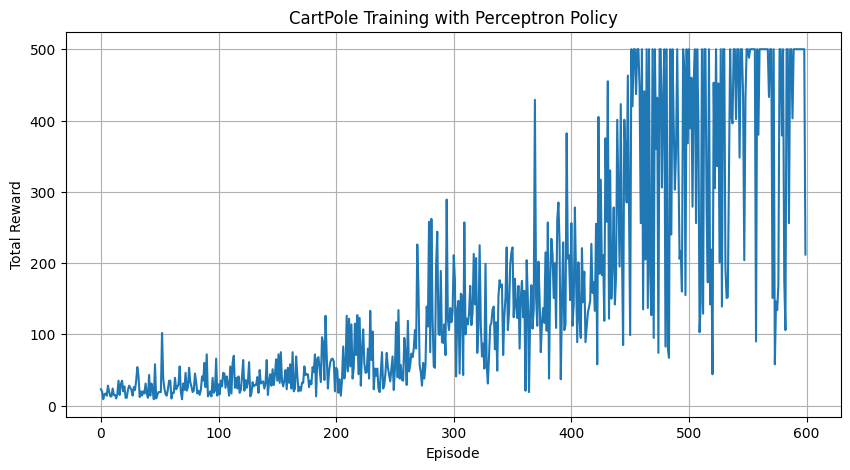

In [8]:
# -----------------------------
# 8. Plot training curve
# -----------------------------
plt.figure(figsize=(10, 5))
plt.plot(reward_history)
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("CartPole Training with Perceptron Policy")
plt.grid(True)
plt.show()

In [9]:
# -----------------------------
# 9. Save trained model
# -----------------------------
torch.save(policy.state_dict(), "perceptron_cartpole_policy.pth")
print("Training complete. Model saved as perceptron_cartpole_policy.pth")
print("Transitions saved as cartpole_transitions.csv")

Training complete. Model saved as perceptron_cartpole_policy.pth
Transitions saved as cartpole_transitions.csv
